# CASALS L1B sweep peak georeferencing validation

This notebook validates the CASALS L1B endpoint-interpolation rule for one H5 file and one sweep.

The main goal is to test whether the waveform-bin coordinates derived from the first and last georeferenced bins are consistent with the official strongest-return `refh` point.

The notebook deliberately separates three concepts:

1. **Primary geometric validation**: interpolate in ECEF Cartesian coordinates.
2. **Projected-coordinate validation**: interpolate in a local projected CRS, by default WGS84 UTM inferred from the H5 footprint.
3. **Provider-literal check**: interpolate longitude, latitude, and elevation component-wise.

Only the strongest RX peak, i.e. the waveform `argmax` bin, should be directly compared with the official `refh`. Other local peaks can be assigned derived coordinates, but they are not official CASALS discrete returns.


In [1]:
from pathlib import Path

# ---------------------------------------------------------------------
# User configuration
# ---------------------------------------------------------------------

# Intended location:
#   CASALS_L1B/notebooks/
# The code also works if run from the CASALS_L1B root.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name.lower() == "notebooks" else NOTEBOOK_DIR

H5_PATH = PROJECT_ROOT / "casals_h5_downloads" / "casals_l1b_20241112T165718_001_02.h5"

# Set to None to use the middle available sweep.
SELECTED_SWEEP_NUM = 7040

# Local peak extraction. The strongest peak / argmax is always included.
TOP_LOCAL_PEAKS_PER_TRACK = 5
LOCAL_PEAK_MIN_DISTANCE_BINS = 20
LOCAL_PEAK_MIN_PROMINENCE_SIGMA = 5.0

# Output location.
OUT_ROOT = PROJECT_ROOT / "outputs" / "sweep_peak_georef_rigorous_validation"

# Plot settings.
FIG_DPI = 160
MAX_WAVEFORM_DISPLAY_BINS = None

# Coordinate policy.
# Primary validation always uses ECEF.
# Projected validation uses an auto-inferred WGS84 UTM CRS unless PROJECTED_EPSG_OVERRIDE is set.
PROJECTED_EPSG_OVERRIDE = None  # Example: 32618

print("PROJECT_ROOT:", PROJECT_ROOT)
print("H5_PATH:", H5_PATH)


PROJECT_ROOT: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B
H5_PATH: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5


In [2]:
import json
import math
import warnings
from dataclasses import dataclass
from typing import Any

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from pyproj import CRS, Geod, Transformer
    HAS_PYPROJ = True
except Exception as exc:
    HAS_PYPROJ = False
    PYPROJ_IMPORT_ERROR = exc

if not HAS_PYPROJ:
    raise ImportError(
        "This notebook requires pyproj for rigorous ECEF/projected-coordinate validation. "
        "Install it with: pip install pyproj"
    ) from PYPROJ_IMPORT_ERROR

pd.set_option("display.max_columns", 240)
pd.set_option("display.width", 260)

print("HAS_SCIPY:", HAS_SCIPY)
print("HAS_PYPROJ:", HAS_PYPROJ)


HAS_SCIPY: True
HAS_PYPROJ: True


## 1. H5 dataset discovery

The code searches by dataset basename so that it works whether fields are stored at the H5 root or under groups. It still fails loudly if a required field is missing.


In [3]:
FIELD_CANDIDATES = {
    "sweep_num": ["sweep_num", "sweep", "sweep_number"],
    "track_num": ["track_num", "track", "track_number"],
    "rx_waveform": ["rx_waveform", "rxwaveform", "rx"],
    "rx_bins": ["rx_bins", "rx_bin", "rxbin"],

    "rwstart_longitude": ["rwstart_longitude", "rw_start_longitude", "rwstart_lon", "rw_start_lon"],
    "rwstart_latitude": ["rwstart_latitude", "rw_start_latitude", "rwstart_lat", "rw_start_lat"],
    "rwstart": ["rwstart", "rw_start", "rwstart_height", "rw_start_height", "rwstart_elevation"],

    "rwstop_longitude": ["rwstop_longitude", "rw_stop_longitude", "rwstop_lon", "rw_stop_lon"],
    "rwstop_latitude": ["rwstop_latitude", "rw_stop_latitude", "rwstop_lat", "rw_stop_lat"],
    "rwstop": ["rwstop", "rw_stop", "rwstop_height", "rw_stop_height", "rwstop_elevation"],

    "refh_longitude": ["refh_longitude", "refh_lon"],
    "refh_latitude": ["refh_latitude", "refh_lat"],
    "refh": ["refh", "refh_height", "refh_elevation"],

    "refh_bounce_time_offset": ["refh_bounce_time_offset", "refh_time_offset", "refh_bounce_time"],
    "rwstart_bounce_time_offset": ["rwstart_bounce_time_offset", "rw_start_bounce_time_offset", "rwstart_time_offset"],
    "rwstop_bounce_time_offset": ["rwstop_bounce_time_offset", "rw_stop_bounce_time_offset", "rwstop_time_offset"],

    "bin_size": ["bin_size"],
    "refh_snr": ["refh_snr"],
    "refh_amp": ["refh_amp"],
    "good_snr": ["good_snr"],
}

REQUIRED_FIELDS = [
    "sweep_num", "track_num", "rx_waveform",
    "rwstart_longitude", "rwstart_latitude", "rwstart",
    "rwstop_longitude", "rwstop_latitude", "rwstop",
    "refh_longitude", "refh_latitude", "refh",
]


def list_datasets(h5: h5py.File) -> dict[str, str]:
    out = {}

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            out[name.split("/")[-1].lower()] = name

    h5.visititems(visitor)
    return out


def find_dataset_path(h5: h5py.File, canonical_name: str) -> str | None:
    by_basename = list_datasets(h5)
    for candidate in FIELD_CANDIDATES.get(canonical_name, [canonical_name]):
        path = by_basename.get(candidate.lower())
        if path is not None:
            return path
    return None


def require_paths(h5: h5py.File) -> dict[str, str]:
    paths = {}
    for field in FIELD_CANDIDATES:
        p = find_dataset_path(h5, field)
        if p is not None:
            paths[field] = p

    missing = [field for field in REQUIRED_FIELDS if field not in paths]
    if missing:
        raise KeyError(f"Missing required H5 datasets: {missing}")

    return paths


def take_1d(ds: h5py.Dataset, idx: np.ndarray | slice | None = None) -> np.ndarray:
    arr = ds if idx is None else ds
    if idx is None:
        out = np.asarray(ds[...])
    elif isinstance(idx, slice):
        out = np.asarray(ds[idx])
    else:
        idx = np.asarray(idx, dtype=np.int64)
        order = np.argsort(idx, kind="mergesort")
        restore = np.argsort(order, kind="mergesort")
        out = np.asarray(ds[idx[order]])[restore]
    return np.asarray(out).squeeze()


def take_waveform_rows(ds: h5py.Dataset, idx: np.ndarray, n_records: int) -> np.ndarray:
    idx = np.asarray(idx, dtype=np.int64)
    order = np.argsort(idx, kind="mergesort")
    restore = np.argsort(order, kind="mergesort")

    if ds.ndim != 2:
        raise ValueError(f"rx_waveform must be 2-D, got shape {ds.shape}")

    if ds.shape[0] == n_records:
        rx = np.asarray(ds[idx[order], :], dtype=np.float32)[restore, :]
    elif ds.shape[1] == n_records:
        rx = np.asarray(ds[:, idx[order]], dtype=np.float32)[:, restore].T
    else:
        raise ValueError(
            f"Cannot align rx_waveform shape {ds.shape} with n_records={n_records}. "
            "Expected records on axis 0 or axis 1."
        )

    return rx


def read_1d_field(h5: h5py.File, paths: dict[str, str], field: str, idx: np.ndarray | None = None) -> np.ndarray:
    if field not in paths:
        raise KeyError(field)
    return take_1d(h5[paths[field]], idx)


with h5py.File(H5_PATH, "r") as h5:
    paths = require_paths(h5)
    print("Resolved H5 dataset paths:")
    for k in sorted(paths):
        print(f"  {k:30s} -> {paths[k]}")


Resolved H5 dataset paths:
  bin_size                       -> bin_size
  good_snr                       -> good_snr
  refh                           -> refh
  refh_amp                       -> refh_amp
  refh_bounce_time_offset        -> refh_bounce_time_offset
  refh_latitude                  -> refh_latitude
  refh_longitude                 -> refh_longitude
  refh_snr                       -> refh_snr
  rwstart                        -> rwstart
  rwstart_bounce_time_offset     -> rwstart_bounce_time_offset
  rwstart_latitude               -> rwstart_latitude
  rwstart_longitude              -> rwstart_longitude
  rwstop                         -> rwstop
  rwstop_bounce_time_offset      -> rwstop_bounce_time_offset
  rwstop_latitude                -> rwstop_latitude
  rwstop_longitude               -> rwstop_longitude
  rx_bins                        -> rx_bins
  rx_waveform                    -> rx_waveform
  sweep_num                      -> sweep_num
  track_num                  

## 2. Select one sweep and load all tracks

The selected sweep is loaded as a matrix with shape `[tracks, rx_bins]`. Records are sorted by `track_num`, and duplicate tracks are reported.


In [4]:
@dataclass
class SweepData:
    sweep_num: int
    record_indices: np.ndarray
    track_num: np.ndarray
    rx: np.ndarray
    n_bins: int
    attrs: dict[str, Any]
    fields: dict[str, np.ndarray]


def choose_sweep(sweep_arr: np.ndarray, requested_sweep: int | None) -> int:
    finite = sweep_arr[np.isfinite(sweep_arr)]
    unique = np.unique(finite.astype(np.int64))
    if unique.size == 0:
        raise ValueError("sweep_num contains no finite values.")

    if requested_sweep is None:
        return int(unique[len(unique) // 2])

    if int(requested_sweep) not in set(unique.tolist()):
        raise ValueError(
            f"Requested sweep {requested_sweep} was not found. "
            f"Available range: {int(unique.min())} to {int(unique.max())}."
        )
    return int(requested_sweep)


def serialize_attr_value(v: object) -> object:
    if isinstance(v, bytes):
        return v.decode("utf-8", errors="replace")
    if isinstance(v, np.generic):
        return v.item()
    if hasattr(v, "tolist"):
        return v.tolist()
    return v


def load_sweep(h5_path: Path, selected_sweep: int | None) -> tuple[SweepData, dict[str, str]]:
    with h5py.File(h5_path, "r") as h5:
        paths = require_paths(h5)

        sweep_arr = read_1d_field(h5, paths, "sweep_num")
        track_arr = read_1d_field(h5, paths, "track_num")
        n_records = int(len(sweep_arr))

        sweep_num = choose_sweep(sweep_arr, selected_sweep)
        idx = np.flatnonzero(sweep_arr.astype(np.int64) == int(sweep_num))
        if idx.size == 0:
            raise ValueError(f"No records found for sweep {sweep_num}.")

        tracks = track_arr[idx].astype(np.int64)
        order = np.argsort(tracks, kind="mergesort")
        idx = idx[order]
        tracks = tracks[order]

        unique_tracks, first_pos, counts = np.unique(tracks, return_index=True, return_counts=True)
        duplicate_count = int(np.sum(counts > 1))
        if duplicate_count:
            warnings.warn(
                f"Sweep {sweep_num} has {duplicate_count} duplicated track numbers. "
                "Keeping the first occurrence after sorting by track."
            )
            keep = np.sort(first_pos)
            idx = idx[keep]
            tracks = tracks[keep]
            order = np.argsort(tracks, kind="mergesort")
            idx = idx[order]
            tracks = tracks[order]

        rx = take_waveform_rows(h5[paths["rx_waveform"]], idx, n_records=n_records)
        n_bins = int(rx.shape[1])

        fields = {}
        for field in [
            "rwstart_longitude", "rwstart_latitude", "rwstart",
            "rwstop_longitude", "rwstop_latitude", "rwstop",
            "refh_longitude", "refh_latitude", "refh",
            "refh_bounce_time_offset", "rwstart_bounce_time_offset", "rwstop_bounce_time_offset",
            "bin_size", "refh_snr", "refh_amp", "good_snr",
        ]:
            if field in paths:
                fields[field] = read_1d_field(h5, paths, field, idx)

        attrs = {str(k): serialize_attr_value(v) for k, v in h5.attrs.items()}

    return SweepData(
        sweep_num=int(sweep_num),
        record_indices=idx.astype(np.int64),
        track_num=tracks.astype(np.int64),
        rx=rx,
        n_bins=n_bins,
        attrs=attrs,
        fields=fields,
    ), paths


sweep_data, paths = load_sweep(H5_PATH, SELECTED_SWEEP_NUM)

print("Selected sweep:", sweep_data.sweep_num)
print("Number of tracks:", len(sweep_data.track_num))
print("Track range:", int(np.min(sweep_data.track_num)), "to", int(np.max(sweep_data.track_num)))
print("RX matrix shape [tracks, bins]:", sweep_data.rx.shape)

if "rx_bins" in paths:
    with h5py.File(H5_PATH, "r") as h5:
        rx_bins = np.asarray(h5[paths["rx_bins"]][...]).squeeze()
    if rx_bins.ndim == 1 and len(rx_bins) == sweep_data.n_bins:
        print("rx_bins are sequential indices:", bool(np.array_equal(rx_bins, np.arange(sweep_data.n_bins))))
    else:
        print("rx_bins dataset exists but is not a simple 1-D bin index array:", rx_bins.shape)


Selected sweep: 7040
Number of tracks: 256
Track range: 0 to 255
RX matrix shape [tracks, bins]: (256, 2728)
rx_bins are sequential indices: True


## 3. Detect strongest and local waveform peaks

For validation against official `refh`, the strongest peak is the RX waveform `argmax` bin. Additional local peaks are exported as derived waveform-peak coordinates, but they are not official discrete returns.


In [5]:
def estimate_noise_sigma(y: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    edge = max(20, min(y.size // 10, 200))
    bg = np.concatenate([y[:edge], y[-edge:]]) if y.size >= 2 * edge else y

    med = float(np.nanmedian(bg))
    mad = float(np.nanmedian(np.abs(bg - med)))
    sigma = 1.4826 * mad if mad > 0 else float(np.nanstd(bg))

    return sigma if np.isfinite(sigma) and sigma > 0 else np.nan


def detect_top_local_peaks(
    y: np.ndarray,
    top_k: int,
    min_distance_bins: int,
    min_prominence_sigma: float,
) -> pd.DataFrame:
    y = np.asarray(y, dtype=float)
    argmax_bin = int(np.nanargmax(y))
    sigma = estimate_noise_sigma(y)

    if HAS_SCIPY:
        prominence = None if not np.isfinite(sigma) else min_prominence_sigma * sigma
        peaks, props = find_peaks(y, distance=min_distance_bins, prominence=prominence)
        if peaks.size == 0:
            peaks, props = find_peaks(y, distance=min_distance_bins)
    else:
        mid = np.where((y[1:-1] >= y[:-2]) & (y[1:-1] >= y[2:]))[0] + 1
        order = np.argsort(y[mid])[::-1]
        kept = []
        for p in mid[order]:
            if all(abs(int(p) - int(q)) >= min_distance_bins for q in kept):
                kept.append(int(p))
            if len(kept) >= max(top_k * 3, top_k):
                break
        peaks = np.asarray(kept, dtype=int)

    # Always include the strongest peak, even if scipy's local-peak logic filters it.
    peaks = np.unique(np.concatenate([peaks.astype(int), np.array([argmax_bin], dtype=int)]))
    amps = y[peaks]
    order = np.argsort(amps)[::-1]
    peaks = peaks[order][:top_k]
    amps = amps[order][:top_k]

    return pd.DataFrame({
        "peak_rank_by_amplitude": np.arange(1, len(peaks) + 1, dtype=int),
        "peak_bin": peaks.astype(int),
        "peak_amp": amps.astype(float),
        "is_argmax": peaks.astype(int) == argmax_bin,
        "argmax_bin": argmax_bin,
        "argmax_amp": float(y[argmax_bin]),
        "noise_sigma_estimate": sigma,
    })


argmax_bins = np.argmax(sweep_data.rx, axis=1).astype(int)
argmax_amps = sweep_data.rx[np.arange(sweep_data.rx.shape[0]), argmax_bins].astype(float)

strongest_df = pd.DataFrame({
    "row_i": np.arange(len(sweep_data.track_num), dtype=int),
    "record_index": sweep_data.record_indices.astype(int),
    "sweep_num": int(sweep_data.sweep_num),
    "track_num": sweep_data.track_num.astype(int),
    "strongest_peak_bin": argmax_bins,
    "strongest_peak_amp": argmax_amps,
})

peak_rows = []
for row_i, track in enumerate(sweep_data.track_num):
    p = detect_top_local_peaks(
        sweep_data.rx[row_i],
        top_k=TOP_LOCAL_PEAKS_PER_TRACK,
        min_distance_bins=LOCAL_PEAK_MIN_DISTANCE_BINS,
        min_prominence_sigma=LOCAL_PEAK_MIN_PROMINENCE_SIGMA,
    )
    p.insert(0, "row_i", row_i)
    p.insert(1, "record_index", int(sweep_data.record_indices[row_i]))
    p.insert(2, "sweep_num", int(sweep_data.sweep_num))
    p.insert(3, "track_num", int(track))
    peak_rows.append(p)

local_peak_df = pd.concat(peak_rows, ignore_index=True) if peak_rows else pd.DataFrame()

display(strongest_df.head())
display(local_peak_df.head(12))
print("Strongest rows:", len(strongest_df))
print("Local peak rows:", len(local_peak_df))


,row_i,record_index,sweep_num,track_num,strongest_peak_bin,strongest_peak_amp
0,0,1802240,7040,0,859,474.0
1,1,1802272,7040,1,1603,684.0
2,2,1802304,7040,2,426,539.0
3,3,1802336,7040,3,1813,414.0
4,4,1802368,7040,4,620,566.0


,row_i,record_index,sweep_num,track_num,peak_rank_by_amplitude,peak_bin,peak_amp,is_argmax,argmax_bin,argmax_amp,noise_sigma_estimate
0,0,1802240,7040,0,1,859,474.0,True,859,474.0,74.1300
1,0,1802240,7040,0,2,2159,440.0,False,859,474.0,74.1300
2,0,1802240,7040,0,3,469,439.0,False,859,474.0,74.1300
3,0,1802240,7040,0,4,2465,426.0,False,859,474.0,74.1300
4,0,1802240,7040,0,5,1246,371.0,False,859,474.0,74.1300
5,1,1802272,7040,1,1,1603,684.0,True,1603,684.0,94.1451
6,1,1802272,7040,1,2,1216,477.0,False,1603,684.0,94.1451
7,1,1802272,7040,1,3,2169,390.0,False,1603,684.0,94.1451
8,1,1802272,7040,1,4,824,389.0,False,1603,684.0,94.1451
9,1,1802272,7040,1,5,1435,355.0,False,1603,684.0,94.1451


Strongest rows: 256
Local peak rows: 1182


## 4. Coordinate interpolation formulas

Let a waveform contain `N` receive bins. For a bin index `b`, use the fractional coordinate

$$
t_b = \frac{b}{N - 1}.
$$

### Primary ECEF interpolation

Convert the first and last bin georeferences to ECEF Cartesian coordinates:

$$
\mathbf{x}_0 = T(\lambda_0, \phi_0, h_0),
\qquad
\mathbf{x}_1 = T(\lambda_1, \phi_1, h_1).
$$

Interpolate in ECEF:

$$
\mathbf{x}_b = \mathbf{x}_0 + t_b(\mathbf{x}_1 - \mathbf{x}_0).
$$

Then transform the interpolated ECEF point back to longitude, latitude, and height.

### Projected-coordinate interpolation

For a local projected CRS, such as WGS84 UTM, use

$$
E_b = E_0 + t_b(E_1 - E_0),
$$

$$
N_b = N_0 + t_b(N_1 - N_0),
$$

$$
h_b = h_0 + t_b(h_1 - h_0).
$$

### Provider-literal component-wise check

The provider's wording can also be tested directly:

$$
\lambda_b = \lambda_0 + t_b(\lambda_1 - \lambda_0),
$$

$$
\phi_b = \phi_0 + t_b(\phi_1 - \phi_0),
$$

$$
h_b = h_0 + t_b(h_1 - h_0).
$$

This component-wise longitude/latitude interpolation is not the primary geometric implementation, but it is useful as a direct check of the provider's statement.


In [6]:
geod = Geod(ellps="WGS84")
lla_to_ecef = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
ecef_to_lla = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)


def infer_wgs84_utm_epsg(lon: np.ndarray, lat: np.ndarray) -> int:
    lon_med = float(np.nanmedian(lon))
    lat_med = float(np.nanmedian(lat))
    zone = int(math.floor((lon_med + 180.0) / 6.0) + 1)
    zone = min(max(zone, 1), 60)
    return (32600 + zone) if lat_med >= 0 else (32700 + zone)


all_lon_for_crs = np.concatenate([
    sweep_data.fields["rwstart_longitude"].astype(float),
    sweep_data.fields["rwstop_longitude"].astype(float),
    sweep_data.fields["refh_longitude"].astype(float),
])
all_lat_for_crs = np.concatenate([
    sweep_data.fields["rwstart_latitude"].astype(float),
    sweep_data.fields["rwstop_latitude"].astype(float),
    sweep_data.fields["refh_latitude"].astype(float),
])

PROJECTED_EPSG = int(PROJECTED_EPSG_OVERRIDE) if PROJECTED_EPSG_OVERRIDE is not None else infer_wgs84_utm_epsg(all_lon_for_crs, all_lat_for_crs)
PROJECTED_CRS = CRS.from_epsg(PROJECTED_EPSG)

lla_to_proj = Transformer.from_crs("EPSG:4326", PROJECTED_CRS, always_xy=True)
proj_to_lla = Transformer.from_crs(PROJECTED_CRS, "EPSG:4326", always_xy=True)

print("Projected CRS:", PROJECTED_CRS.to_string())


def lon_shortest_delta_deg(lon0: np.ndarray, lon1: np.ndarray) -> np.ndarray:
    return (np.asarray(lon1, float) - np.asarray(lon0, float) + 180.0) % 360.0 - 180.0


def normalize_lon_deg(lon: np.ndarray) -> np.ndarray:
    return (np.asarray(lon, float) + 180.0) % 360.0 - 180.0


def t_from_bin(bin_index: np.ndarray, n_bins: int) -> np.ndarray:
    return np.asarray(bin_index, dtype=float) / float(n_bins - 1)


def geodetic_to_ecef(lon: np.ndarray, lat: np.ndarray, h: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    x, y, z = lla_to_ecef.transform(lon, lat, h)
    return np.asarray(x, float), np.asarray(y, float), np.asarray(z, float)


def ecef_to_geodetic(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    lon, lat, h = ecef_to_lla.transform(x, y, z)
    return np.asarray(lon, float), np.asarray(lat, float), np.asarray(h, float)


def interpolate_ecef(lon0, lat0, h0, lon1, lat1, h1, bin_index, n_bins) -> dict[str, np.ndarray]:
    t = t_from_bin(bin_index, n_bins)
    x0, y0, z0 = geodetic_to_ecef(lon0, lat0, h0)
    x1, y1, z1 = geodetic_to_ecef(lon1, lat1, h1)

    x = x0 + t * (x1 - x0)
    y = y0 + t * (y1 - y0)
    z = z0 + t * (z1 - z0)
    lon, lat, h = ecef_to_geodetic(x, y, z)

    segment_length = np.sqrt((x1 - x0) ** 2 + (y1 - y0) ** 2 + (z1 - z0) ** 2)
    spacing = segment_length / float(n_bins - 1)

    return {
        "t": t,
        "lon": lon,
        "lat": lat,
        "h": h,
        "ecef_x": x,
        "ecef_y": y,
        "ecef_z": z,
        "segment_length_m": segment_length,
        "segment_spacing_m_per_bin": spacing,
    }


def interpolate_projected(lon0, lat0, h0, lon1, lat1, h1, bin_index, n_bins) -> dict[str, np.ndarray]:
    t = t_from_bin(bin_index, n_bins)

    e0, n0 = lla_to_proj.transform(lon0, lat0)
    e1, n1 = lla_to_proj.transform(lon1, lat1)

    e = np.asarray(e0, float) + t * (np.asarray(e1, float) - np.asarray(e0, float))
    n = np.asarray(n0, float) + t * (np.asarray(n1, float) - np.asarray(n0, float))
    h = np.asarray(h0, float) + t * (np.asarray(h1, float) - np.asarray(h0, float))

    lon, lat = proj_to_lla.transform(e, n)
    x, y, z = geodetic_to_ecef(lon, lat, h)

    return {
        "t": t,
        "lon": np.asarray(lon, float),
        "lat": np.asarray(lat, float),
        "h": h,
        "proj_e": e,
        "proj_n": n,
        "ecef_x": x,
        "ecef_y": y,
        "ecef_z": z,
    }


def interpolate_componentwise_lnh(lon0, lat0, h0, lon1, lat1, h1, bin_index, n_bins) -> dict[str, np.ndarray]:
    t = t_from_bin(bin_index, n_bins)

    lon = normalize_lon_deg(
        np.asarray(lon0, float)
        + t * lon_shortest_delta_deg(np.asarray(lon0, float), np.asarray(lon1, float))
    )
    lat = np.asarray(lat0, float) + t * (np.asarray(lat1, float) - np.asarray(lat0, float))
    h = np.asarray(h0, float) + t * (np.asarray(h1, float) - np.asarray(h0, float))
    x, y, z = geodetic_to_ecef(lon, lat, h)

    return {
        "t": t,
        "lon": lon,
        "lat": lat,
        "h": h,
        "ecef_x": x,
        "ecef_y": y,
        "ecef_z": z,
    }


def horizontal_distance_m(lon_a, lat_a, lon_b, lat_b) -> np.ndarray:
    _, _, dist = geod.inv(lon_a, lat_a, lon_b, lat_b)
    return np.asarray(dist, dtype=float)


def ecef_distance_m(xa, ya, za, xb, yb, zb) -> np.ndarray:
    return np.sqrt(
        (np.asarray(xa, float) - np.asarray(xb, float)) ** 2
        + (np.asarray(ya, float) - np.asarray(yb, float)) ** 2
        + (np.asarray(za, float) - np.asarray(zb, float)) ** 2
    )


def add_method_coordinates(
    out: pd.DataFrame,
    method_prefix: str,
    method: str,
    bin_col: str,
) -> pd.DataFrame:
    row_i = out["row_i"].to_numpy(dtype=int)

    lon0 = sweep_data.fields["rwstart_longitude"][row_i]
    lat0 = sweep_data.fields["rwstart_latitude"][row_i]
    h0 = sweep_data.fields["rwstart"][row_i]
    lon1 = sweep_data.fields["rwstop_longitude"][row_i]
    lat1 = sweep_data.fields["rwstop_latitude"][row_i]
    h1 = sweep_data.fields["rwstop"][row_i]
    b = out[bin_col].to_numpy(dtype=float)

    if method == "ecef":
        res = interpolate_ecef(lon0, lat0, h0, lon1, lat1, h1, b, sweep_data.n_bins)
    elif method == "projected":
        res = interpolate_projected(lon0, lat0, h0, lon1, lat1, h1, b, sweep_data.n_bins)
    elif method == "component":
        res = interpolate_componentwise_lnh(lon0, lat0, h0, lon1, lat1, h1, b, sweep_data.n_bins)
    else:
        raise ValueError(method)

    for k, v in res.items():
        out[f"{method_prefix}_{k}"] = v

    return out


def add_endpoint_and_refh_columns(out: pd.DataFrame) -> pd.DataFrame:
    row_i = out["row_i"].to_numpy(dtype=int)

    out["rwstart_lon"] = sweep_data.fields["rwstart_longitude"][row_i]
    out["rwstart_lat"] = sweep_data.fields["rwstart_latitude"][row_i]
    out["rwstart_h"] = sweep_data.fields["rwstart"][row_i]
    out["rwstop_lon"] = sweep_data.fields["rwstop_longitude"][row_i]
    out["rwstop_lat"] = sweep_data.fields["rwstop_latitude"][row_i]
    out["rwstop_h"] = sweep_data.fields["rwstop"][row_i]

    out["refh_lon"] = sweep_data.fields["refh_longitude"][row_i]
    out["refh_lat"] = sweep_data.fields["refh_latitude"][row_i]
    out["refh_h"] = sweep_data.fields["refh"][row_i]

    ref_x, ref_y, ref_z = geodetic_to_ecef(out["refh_lon"].to_numpy(), out["refh_lat"].to_numpy(), out["refh_h"].to_numpy())
    out["refh_ecef_x"] = ref_x
    out["refh_ecef_y"] = ref_y
    out["refh_ecef_z"] = ref_z

    return out


def add_error_to_refh(out: pd.DataFrame, prefix: str, label: str | None = None) -> pd.DataFrame:
    label = prefix if label is None else label

    out[f"{label}_horizontal_error_to_refh_m"] = horizontal_distance_m(
        out[f"{prefix}_lon"].to_numpy(),
        out[f"{prefix}_lat"].to_numpy(),
        out["refh_lon"].to_numpy(),
        out["refh_lat"].to_numpy(),
    )
    out[f"{label}_vertical_error_to_refh_m"] = out[f"{prefix}_h"].to_numpy() - out["refh_h"].to_numpy()
    out[f"{label}_abs_vertical_error_to_refh_m"] = np.abs(out[f"{label}_vertical_error_to_refh_m"])
    out[f"{label}_3d_error_to_refh_m"] = np.sqrt(
        out[f"{label}_horizontal_error_to_refh_m"].to_numpy() ** 2
        + out[f"{label}_vertical_error_to_refh_m"].to_numpy() ** 2
    )
    out[f"{label}_ecef_distance_to_refh_m"] = ecef_distance_m(
        out[f"{prefix}_ecef_x"].to_numpy(),
        out[f"{prefix}_ecef_y"].to_numpy(),
        out[f"{prefix}_ecef_z"].to_numpy(),
        out["refh_ecef_x"].to_numpy(),
        out["refh_ecef_y"].to_numpy(),
        out["refh_ecef_z"].to_numpy(),
    )

    return out


def add_method_difference(out: pd.DataFrame, a_prefix: str, b_prefix: str, label: str) -> pd.DataFrame:
    out[f"{label}_horizontal_diff_m"] = horizontal_distance_m(
        out[f"{a_prefix}_lon"].to_numpy(),
        out[f"{a_prefix}_lat"].to_numpy(),
        out[f"{b_prefix}_lon"].to_numpy(),
        out[f"{b_prefix}_lat"].to_numpy(),
    )
    out[f"{label}_vertical_diff_m"] = out[f"{a_prefix}_h"].to_numpy() - out[f"{b_prefix}_h"].to_numpy()
    out[f"{label}_3d_diff_m"] = np.sqrt(
        out[f"{label}_horizontal_diff_m"].to_numpy() ** 2
        + out[f"{label}_vertical_diff_m"].to_numpy() ** 2
    )
    out[f"{label}_ecef_diff_m"] = ecef_distance_m(
        out[f"{a_prefix}_ecef_x"].to_numpy(),
        out[f"{a_prefix}_ecef_y"].to_numpy(),
        out[f"{a_prefix}_ecef_z"].to_numpy(),
        out[f"{b_prefix}_ecef_x"].to_numpy(),
        out[f"{b_prefix}_ecef_y"].to_numpy(),
        out[f"{b_prefix}_ecef_z"].to_numpy(),
    )
    return out


Projected CRS: EPSG:32618


## 5. Strongest peak validation against official `refh`

This is the core validation.

The integer waveform argmax bin is expected to close to the official `refh` only up to bin quantization. If the official `refh` is stored at a continuous sub-bin time position, the integer argmax residual should be bounded by roughly half a bin.

The stronger validation uses the `refh_bounce_time_offset` field, when available:

$$
t_{\mathrm{refh}} =
\frac{\tau_{\mathrm{refh}} - \tau_0}{\tau_1 - \tau_0}.
$$

The corresponding continuous bin coordinate is

$$
b_{\mathrm{refh}} = t_{\mathrm{refh}}(N - 1).
$$


In [7]:
def build_georef_for_bins(df: pd.DataFrame, bin_col: str, prefix_root: str) -> pd.DataFrame:
    out = df.copy()
    out = add_endpoint_and_refh_columns(out)

    out = add_method_coordinates(out, f"{prefix_root}_ecef", "ecef", bin_col)
    out = add_method_coordinates(out, f"{prefix_root}_projected", "projected", bin_col)
    out = add_method_coordinates(out, f"{prefix_root}_component", "component", bin_col)

    out = add_error_to_refh(out, f"{prefix_root}_ecef", label=f"{prefix_root}_ecef")
    out = add_error_to_refh(out, f"{prefix_root}_projected", label=f"{prefix_root}_projected")
    out = add_error_to_refh(out, f"{prefix_root}_component", label=f"{prefix_root}_component")

    out = add_method_difference(out, f"{prefix_root}_projected", f"{prefix_root}_ecef", f"{prefix_root}_projected_vs_ecef")
    out = add_method_difference(out, f"{prefix_root}_component", f"{prefix_root}_ecef", f"{prefix_root}_component_vs_ecef")

    return out


strongest_geo_df = build_georef_for_bins(
    strongest_df,
    bin_col="strongest_peak_bin",
    prefix_root="argmax_bin",
)

has_time_offsets = all(k in sweep_data.fields for k in [
    "refh_bounce_time_offset", "rwstart_bounce_time_offset", "rwstop_bounce_time_offset"
])

if has_time_offsets:
    rt = sweep_data.fields["refh_bounce_time_offset"].astype(float)
    st = sweep_data.fields["rwstart_bounce_time_offset"].astype(float)
    et = sweep_data.fields["rwstop_bounce_time_offset"].astype(float)
    denom = et - st

    refh_time_fraction = np.divide(
        rt - st,
        denom,
        out=np.full_like(rt, np.nan, dtype=float),
        where=np.abs(denom) > 0,
    )
    predicted_refh_bin_float = refh_time_fraction * float(sweep_data.n_bins - 1)

    strongest_geo_df["refh_time_fraction"] = refh_time_fraction
    strongest_geo_df["predicted_refh_bin_float"] = predicted_refh_bin_float
    strongest_geo_df["argmax_bin_minus_predicted_refh_bin"] = (
        strongest_geo_df["strongest_peak_bin"].to_numpy(dtype=float) - predicted_refh_bin_float
    )

    refh_fraction_df = strongest_df[["row_i", "record_index", "sweep_num", "track_num"]].copy()
    refh_fraction_df["predicted_refh_bin_float"] = predicted_refh_bin_float

    refh_fraction_geo_df = build_georef_for_bins(
        refh_fraction_df,
        bin_col="predicted_refh_bin_float",
        prefix_root="refh_subbin",
    )
    refh_fraction_geo_df["refh_time_fraction"] = refh_time_fraction
else:
    refh_fraction_geo_df = pd.DataFrame()
    print("Timing offsets were not found. Skipping sub-bin refh-fraction validation.")

# Quantization check: integer argmax error should be comparable to half-bin spacing.
strongest_geo_df["expected_half_bin_spacing_m"] = 0.5 * strongest_geo_df["argmax_bin_ecef_segment_spacing_m_per_bin"]
strongest_geo_df["argmax_ecef_error_over_half_bin_spacing"] = (
    strongest_geo_df["argmax_bin_ecef_ecef_distance_to_refh_m"]
    / strongest_geo_df["expected_half_bin_spacing_m"]
)

display(strongest_geo_df.head())
if len(refh_fraction_geo_df):
    display(refh_fraction_geo_df.head())


,row_i,record_index,sweep_num,track_num,strongest_peak_bin,strongest_peak_amp,rwstart_lon,rwstart_lat,rwstart_h,rwstop_lon,rwstop_lat,rwstop_h,refh_lon,refh_lat,refh_h,refh_ecef_x,refh_ecef_y,refh_ecef_z,argmax_bin_ecef_t,argmax_bin_ecef_lon,argmax_bin_ecef_lat,argmax_bin_ecef_h,argmax_bin_ecef_ecef_x,argmax_bin_ecef_ecef_y,argmax_bin_ecef_ecef_z,argmax_bin_ecef_segment_length_m,argmax_bin_ecef_segment_spacing_m_per_bin,argmax_bin_projected_t,argmax_bin_projected_lon,argmax_bin_projected_lat,argmax_bin_projected_h,argmax_bin_projected_proj_e,argmax_bin_projected_proj_n,argmax_bin_projected_ecef_x,argmax_bin_projected_ecef_y,argmax_bin_projected_ecef_z,argmax_bin_component_t,argmax_bin_component_lon,argmax_bin_component_lat,argmax_bin_component_h,argmax_bin_component_ecef_x,argmax_bin_component_ecef_y,argmax_bin_component_ecef_z,argmax_bin_ecef_horizontal_error_to_refh_m,argmax_bin_ecef_vertical_error_to_refh_m,argmax_bin_ecef_abs_vertical_error_to_refh_m,argmax_bin_ecef_3d_error_to_refh_m,argmax_bin_ecef_ecef_distance_to_refh_m,argmax_bin_projected_horizontal_error_to_refh_m,argmax_bin_projected_vertical_error_to_refh_m,argmax_bin_projected_abs_vertical_error_to_refh_m,argmax_bin_projected_3d_error_to_refh_m,argmax_bin_projected_ecef_distance_to_refh_m,argmax_bin_component_horizontal_error_to_refh_m,argmax_bin_component_vertical_error_to_refh_m,argmax_bin_component_abs_vertical_error_to_refh_m,argmax_bin_component_3d_error_to_refh_m,argmax_bin_component_ecef_distance_to_refh_m,argmax_bin_projected_vs_ecef_horizontal_diff_m,argmax_bin_projected_vs_ecef_vertical_diff_m,argmax_bin_projected_vs_ecef_3d_diff_m,argmax_bin_projected_vs_ecef_ecef_diff_m,argmax_bin_component_vs_ecef_horizontal_diff_m,argmax_bin_component_vs_ecef_vertical_diff_m,argmax_bin_component_vs_ecef_3d_diff_m,argmax_bin_component_vs_ecef_ecef_diff_m,refh_time_fraction,predicted_refh_bin_float,argmax_bin_minus_predicted_refh_bin,expected_half_bin_spacing_m,argmax_ecef_error_over_half_bin_spacing
0,0,1802240,7040,0,859,474.0,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,-75.285002,38.414235,85.320913,1.271086e+06,-4.839931e+06,3.941627e+06,0.314998,-75.285002,38.414235,85.349085,1.271086e+06,-4.839931e+06,3.941627e+06,408.803707,0.14991,0.314998,-75.285002,38.414235,85.349091,475118.999708,4.251815e+06,1.271086e+06,-4.839931e+06,3.941627e+06,0.314998,-75.285002,38.414235,85.349091,1.271086e+06,-4.839931e+06,3.941627e+06,0.001285,0.028172,0.028172,0.028201,0.028201,0.001027,0.028178,0.028178,0.028197,0.028197,0.001027,0.028178,0.028178,0.028197,0.028197,0.000258,0.000006,0.000259,0.000259,0.000259,0.000006,0.000259,0.000259,0.315066,859.184934,-0.184934,0.074955,0.376244
1,1,1802272,7040,1,1603,684.0,-75.285010,38.414184,213.984330,-75.284967,38.414349,-194.392892,-75.284985,38.414281,-26.057590,1.271065e+06,-4.839843e+06,3.941562e+06,0.587825,-75.284985,38.414281,-26.070200,1.271065e+06,-4.839843e+06,3.941562e+06,408.803707,0.14991,0.587825,-75.284985,38.414281,-26.070194,475120.473254,4.251820e+06,1.271065e+06,-4.839843e+06,3.941562e+06,0.587825,-75.284985,38.414281,-26.070194,1.271065e+06,-4.839843e+06,3.941562e+06,0.000576,-0.012610,0.012610,0.012623,0.012623,0.000866,-0.012603,0.012603,0.012633,0.012633,0.000866,-0.012603,0.012603,0.012633,0.012633,0.000290,0.000007,0.000290,0.000290,0.000291,0.000007,0.000291,0.000291,0.587793,1602.912207,0.087793,0.074955,0.168406
2,2,1802304,7040,2,426,539.0,-75.285006,38.414186,213.994917,-75.284964,38.414350,-194.381754,-75.285000,38.414211,150.148342,1.271100e+06,-4.839981e+06,3.941665e+06,0.156216,-75.285000,38.414211,150.200098,1.271100e+06,-4.839981e+06,3.941666e+06,408.803707,0.14991,0.156216,-75.285000,38.414211,150.200101,475119.175226,4.251813e+06,1.271100e+06,-4.839981e+06,3.941666e+06,0.156216,-75.285000,38.414211,150.200101,1.271100e+06,-4.839981e+06,3.941666e+06,0.002366,0.051755,0.051755,0.051809,0.051809,0.002208,0.051759,0.051759,0.051806,0.051806,0.002208,0.051759,0.051759,0.051806,0.051

,row_i,record_index,sweep_num,track_num,predicted_refh_bin_float,rwstart_lon,rwstart_lat,rwstart_h,rwstop_lon,rwstop_lat,rwstop_h,refh_lon,refh_lat,refh_h,refh_ecef_x,refh_ecef_y,refh_ecef_z,refh_subbin_ecef_t,refh_subbin_ecef_lon,refh_subbin_ecef_lat,refh_subbin_ecef_h,refh_subbin_ecef_ecef_x,refh_subbin_ecef_ecef_y,refh_subbin_ecef_ecef_z,refh_subbin_ecef_segment_length_m,refh_subbin_ecef_segment_spacing_m_per_bin,refh_subbin_projected_t,refh_subbin_projected_lon,refh_subbin_projected_lat,refh_subbin_projected_h,refh_subbin_projected_proj_e,refh_subbin_projected_proj_n,refh_subbin_projected_ecef_x,refh_subbin_projected_ecef_y,refh_subbin_projected_ecef_z,refh_subbin_component_t,refh_subbin_component_lon,refh_subbin_component_lat,refh_subbin_component_h,refh_subbin_component_ecef_x,refh_subbin_component_ecef_y,refh_subbin_component_ecef_z,refh_subbin_ecef_horizontal_error_to_refh_m,refh_subbin_ecef_vertical_error_to_refh_m,refh_subbin_ecef_abs_vertical_error_to_refh_m,refh_subbin_ecef_3d_error_to_refh_m,refh_subbin_ecef_ecef_distance_to_refh_m,refh_subbin_projected_horizontal_error_to_refh_m,refh_subbin_projected_vertical_error_to_refh_m,refh_subbin_projected_abs_vertical_error_to_refh_m,refh_subbin_projected_3d_error_to_refh_m,refh_subbin_projected_ecef_distance_to_refh_m,refh_subbin_component_horizontal_error_to_refh_m,refh_subbin_component_vertical_error_to_refh_m,refh_subbin_component_abs_vertical_error_to_refh_m,refh_subbin_component_3d_error_to_refh_m,refh_subbin_component_ecef_distance_to_refh_m,refh_subbin_projected_vs_ecef_horizontal_diff_m,refh_subbin_projected_vs_ecef_vertical_diff_m,refh_subbin_projected_vs_ecef_3d_diff_m,refh_subbin_projected_vs_ecef_ecef_diff_m,refh_subbin_component_vs_ecef_horizontal_diff_m,refh_subbin_component_vs_ecef_vertical_diff_m,refh_subbin_component_vs_ecef_3d_diff_m,refh_subbin_component_vs_ecef_ecef_diff_m,refh_time_fraction
0,0,1802240,7040,0,859.184934,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,-75.285002,38.414235,85.320913,1.271086e+06,-4.839931e+06,3.941627e+06,0.315066,-75.285002,38.414235,85.321390,1.271086e+06,-4.839931e+06,3.941627e+06,408.803707,0.14991,0.315066,-75.285002,38.414235,85.321396,475118.999961,4.251815e+06,1.271086e+06,-4.839931e+06,3.941627e+06,0.315066,-75.285002,38.414235,85.321396,1.271086e+06,-4.839931e+06,3.941627e+06,0.000020,0.000478,0.000478,0.000478,0.000478,0.000239,0.000483,0.000483,0.000539,0.000539,0.000239,0.000483,0.000483,0.000539,0.000539,0.000259,0.000006,0.000259,0.000259,0.000259,0.000006,0.000259,0.000259,0.315066
1,1,1802272,7040,1,1602.912207,-75.285010,38.414184,213.984330,-75.284967,38.414349,-194.392892,-75.284985,38.414281,-26.057590,1.271065e+06,-4.839843e+06,3.941562e+06,0.587793,-75.284985,38.414281,-26.057053,1.271065e+06,-4.839843e+06,3.941562e+06,408.803707,0.14991,0.587793,-75.284985,38.414281,-26.057046,475120.473133,4.251820e+06,1.271065e+06,-4.839843e+06,3.941562e+06,0.587793,-75.284985,38.414281,-26.057046,1.271065e+06,-4.839843e+06,3.941562e+06,0.000026,0.000538,0.000538,0.000538,0.000538,0.000265,0.000544,0.000544,0.000605,0.000605,0.000265,0.000544,0.000544,0.000605,0.000605,0.000290,0.000007,0.000290,0.000290,0.000291,0.000007,0.000291,0.000291,0.587793
2,2,1802304,7040,2,426.343658,-75.285006,38.414186,213.994917,-75.284964,38.414350,-194.381754,-75.285000,38.414211,150.148342,1.271100e+06,-4.839981e+06,3.941665e+06,0.156342,-75.285000,38.414211,150.148634,1.271100e+06,-4.839981e+06,3.941665e+06,408.803707,0.14991,0.156342,-75.285000,38.414211,150.148637,475119.175702,4.251813e+06,1.271100e+06,-4.839981e+06,3.941665e+06,0.156342,-75.285000,38.414211,150.148637,1.271100e+06,-4.839981e+06,3.941665e+06,0.000013,0.000291,0.000291,0.000292,0.000292,0.000146,0.000295,0.000295,0.000329,0.000329,0.000146,0.000295,0.000295,0.000329,0.000329,0.000158,0.000004,0.000158,0.000158,0.000158,0.000004,0.000158,0.000158,0.156342
3,3,1802336,7040,3,1812.835227,-75.285001,38.414187,214.002153,-75.284959,38.414352,-19

## 6. Summarize validation errors

The most important row is `refh_subbin_ecef_to_refh`, because it uses the official continuous refh time fraction and the geometrically rigorous ECEF interpolation.

The row `argmax_integer_ecef_to_refh` is expected to be slightly larger because the waveform argmax is an integer bin.


In [8]:
def finite_values(df: pd.DataFrame, col: str) -> np.ndarray:
    if col not in df:
        return np.array([], dtype=float)
    x = df[col].to_numpy(dtype=float)
    return x[np.isfinite(x)]


def summarize_numeric(df: pd.DataFrame, cols: dict[str, str]) -> dict[str, float]:
    out = {}
    for label, col in cols.items():
        x = finite_values(df, col)
        if x.size == 0:
            continue
        out[f"{label}_median"] = float(np.nanmedian(x))
        out[f"{label}_p90"] = float(np.nanpercentile(x, 90))
        out[f"{label}_p95"] = float(np.nanpercentile(x, 95))
        out[f"{label}_max"] = float(np.nanmax(x))
    return out


def summarize_error_to_refh(df: pd.DataFrame, prefix: str) -> dict[str, float]:
    return summarize_numeric(df, {
        "horizontal_m": f"{prefix}_horizontal_error_to_refh_m",
        "vertical_m": f"{prefix}_vertical_error_to_refh_m",
        "abs_vertical_m": f"{prefix}_abs_vertical_error_to_refh_m",
        "3d_m": f"{prefix}_3d_error_to_refh_m",
        "ecef_m": f"{prefix}_ecef_distance_to_refh_m",
    })


def summarize_method_diff(df: pd.DataFrame, prefix: str) -> dict[str, float]:
    return summarize_numeric(df, {
        "horizontal_m": f"{prefix}_horizontal_diff_m",
        "vertical_m": f"{prefix}_vertical_diff_m",
        "3d_m": f"{prefix}_3d_diff_m",
        "ecef_m": f"{prefix}_ecef_diff_m",
    })


summary_rows = [
    {
        "test": "argmax_integer_ecef_to_refh",
        "meaning": "Primary geometric check using integer RX argmax bin; residual includes bin quantization.",
        "n_tracks": int(len(strongest_geo_df)),
        **summarize_error_to_refh(strongest_geo_df, "argmax_bin_ecef"),
    },
    {
        "test": "argmax_integer_projected_to_refh",
        "meaning": "Projected-coordinate interpolation using the integer RX argmax bin.",
        "n_tracks": int(len(strongest_geo_df)),
        **summarize_error_to_refh(strongest_geo_df, "argmax_bin_projected"),
    },
    {
        "test": "argmax_integer_component_to_refh",
        "meaning": "Provider-literal lon/lat/h component interpolation using the integer RX argmax bin.",
        "n_tracks": int(len(strongest_geo_df)),
        **summarize_error_to_refh(strongest_geo_df, "argmax_bin_component"),
    },
    {
        "test": "argmax_projected_vs_ecef",
        "meaning": "Difference between projected-coordinate and ECEF interpolation at the integer argmax bin.",
        "n_tracks": int(len(strongest_geo_df)),
        **summarize_method_diff(strongest_geo_df, "argmax_bin_projected_vs_ecef"),
    },
    {
        "test": "argmax_component_vs_ecef",
        "meaning": "Difference between component-wise lon/lat/h and ECEF interpolation at the integer argmax bin.",
        "n_tracks": int(len(strongest_geo_df)),
        **summarize_method_diff(strongest_geo_df, "argmax_bin_component_vs_ecef"),
    },
]

if len(refh_fraction_geo_df):
    summary_rows.extend([
        {
            "test": "refh_subbin_ecef_to_refh",
            "meaning": "Primary closure test using refh bounce-time sub-bin fraction and ECEF interpolation.",
            "n_tracks": int(len(refh_fraction_geo_df)),
            **summarize_error_to_refh(refh_fraction_geo_df, "refh_subbin_ecef"),
        },
        {
            "test": "refh_subbin_projected_to_refh",
            "meaning": "Projected-coordinate closure using refh bounce-time sub-bin fraction.",
            "n_tracks": int(len(refh_fraction_geo_df)),
            **summarize_error_to_refh(refh_fraction_geo_df, "refh_subbin_projected"),
        },
        {
            "test": "refh_subbin_component_to_refh",
            "meaning": "Provider-literal component-wise closure using refh bounce-time sub-bin fraction.",
            "n_tracks": int(len(refh_fraction_geo_df)),
            **summarize_error_to_refh(refh_fraction_geo_df, "refh_subbin_component"),
        },
        {
            "test": "refh_subbin_projected_vs_ecef",
            "meaning": "Difference between projected-coordinate and ECEF interpolation at the official refh sub-bin position.",
            "n_tracks": int(len(refh_fraction_geo_df)),
            **summarize_method_diff(refh_fraction_geo_df, "refh_subbin_projected_vs_ecef"),
        },
        {
            "test": "refh_subbin_component_vs_ecef",
            "meaning": "Difference between component-wise lon/lat/h and ECEF interpolation at the official refh sub-bin position.",
            "n_tracks": int(len(refh_fraction_geo_df)),
            **summarize_method_diff(refh_fraction_geo_df, "refh_subbin_component_vs_ecef"),
        },
    ])

summary_rows.append({
    "test": "argmax_bin_quantization",
    "meaning": "Integer argmax bin minus continuous refh bin predicted from bounce-time fraction.",
    "n_tracks": int(len(strongest_geo_df)),
    **summarize_numeric(strongest_geo_df, {
        "signed_bin_diff": "argmax_bin_minus_predicted_refh_bin",
        "abs_bin_diff": "argmax_bin_minus_predicted_refh_bin",
        "ecef_error_over_half_bin": "argmax_ecef_error_over_half_bin_spacing",
        "segment_spacing_m_per_bin": "argmax_bin_ecef_segment_spacing_m_per_bin",
        "expected_half_bin_spacing_m": "expected_half_bin_spacing_m",
    }),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

if has_time_offsets:
    bin_diff = strongest_geo_df["argmax_bin_minus_predicted_refh_bin"].to_numpy(dtype=float)
    print("Integer argmax bin - continuous refh bin:")
    print("  median signed:", float(np.nanmedian(bin_diff)))
    print("  p90 absolute:", float(np.nanpercentile(np.abs(bin_diff), 90)))
    print("  max absolute:", float(np.nanmax(np.abs(bin_diff))))

    half_spacing = strongest_geo_df["expected_half_bin_spacing_m"].to_numpy(dtype=float)
    print("Expected half-bin spacing in 3D:")
    print("  median:", float(np.nanmedian(half_spacing)), "m")
    print("  p90:", float(np.nanpercentile(half_spacing, 90)), "m")


,test,meaning,n_tracks,horizontal_m_median,horizontal_m_p90,horizontal_m_p95,horizontal_m_max,vertical_m_median,vertical_m_p90,vertical_m_p95,vertical_m_max,abs_vertical_m_median,abs_vertical_m_p90,abs_vertical_m_p95,abs_vertical_m_max,3d_m_median,3d_m_p90,3d_m_p95,3d_m_max,ecef_m_median,ecef_m_p90,ecef_m_p95,ecef_m_max,signed_bin_diff_median,signed_bin_diff_p90,signed_bin_diff_p95,signed_bin_diff_max,abs_bin_diff_median,abs_bin_diff_p90,abs_bin_diff_p95,abs_bin_diff_max,ecef_error_over_half_bin_median,ecef_error_over_half_bin_p90,ecef_error_over_half_bin_p95,ecef_error_over_half_bin_max,segment_spacing_m_per_bin_median,segment_spacing_m_per_bin_p90,segment_spacing_m_per_bin_p95,segment_spacing_m_per_bin_max,expected_half_bin_spacing_m_median,expected_half_bin_spacing_m_p90,expected_half_bin_spacing_m_p95,expected_half_bin_spacing_m_max
0,argmax_integer_ecef_to_refh,Primary geometric check using integer RX argma...,256,0.000666,0.002683,0.003251,0.003638,-0.012939,0.041690,0.057475,0.074197,0.013323,0.054546,0.068287,0.074197,0.013339,0.054612,0.068372,0.074278,0.013339,0.054612,0.068372,0.074278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,argmax_integer_projected_to_refh,Projected-coordinate interpolation using the i...,256,0.000975,0.002691,0.003193,0.003617,-0.012931,0.041695,0.057478,0.074197,0.013315,0.054543,0.068288,0.074197,0.013351,0.054615,0.068371,0.074278,0.013351,0.054615,0.068371,0.074278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,argmax_integer_component_to_refh,Provider-literal lon/lat/h component interpola...,256,0.000976,0.002691,0.003193,0.003617,-0.012931,0.041695,0.057478,0.074197,0.013315,0.054543,0.068288,0.074197,0.013351,0.054615,0.068371,0.074278,0.013351,0.054615,0.068371,0.074278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,argmax_projected_vs_ecef,Difference between projected-coordinate and EC...,256,0.000303,0.000326,0.000328,0.000330,0.000007,0.000008,0.000009,0.000009,NaN,NaN,NaN,NaN,0.000303,0.000326,0.000328,0.000330,0.000303,0.000326,0.000328,0.000330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,argmax_component_vs_ecef,Difference between component-wise lon/lat/h an...,256,0.000303,0.000327,0.000329,0.000331,0.000007,0.000008,0.000009,0.000009,NaN,NaN,NaN,NaN,0.000303,0.000327,0.000329,0.000331,0.000303,0.000327,0.000329,0.000331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,refh_subbin_ecef_to_refh,Primary closure test using refh bounce-time su...,256,0.000024,0.000026,0.000026,0.000030,0.000535,0.000538,0.000549,0.000554,0.000535,0.000538,0.000549,0.000554,0.000536,0.000538,0.000549,0.000555,0.000536,0.000538,0.000549,0.000555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,refh_subbin_projected_to_refh,Projected-coordinate closure using refh bounce...,256,0.000279,0.000301,0.000304,0.000306,0.000543,0.000544,0.000556,0.000562,0.000543,0.000544,0.000556,0.000562,0.000611,0.000623,0.000627,0.000637,0.000611,0.000623,0.000627,0.000637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,refh_subbin_component_to_refh,Provider-literal component-wise closure using ...,256,0.000279,0.000302,0.000305,0.000307,0.000543,0.000544,0.000556,0.000562,0.000543,0.000544,0.000556,0.000562,0.000612,0.000623,0.000627,0.000637,0.000612,0.000623,0.000627,0.000637,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,refh_subbin_projected_vs_ecef,Difference between projected-coordinate and EC...,256,0.000303,0.000326,0.000328,0.000330,0.000007,0.000008,0.000009,0.000009,NaN,NaN,NaN,NaN,0.000303,0.000326,0.000328,0.000330,0.000303,0.000326,0.000328,0.000330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,refh_subbin_component_vs_ecef,Difference between component-wise lon/lat/h an...,256,0.000303,0.000327,0

Integer argmax bin - continuous refh bin:
  median signed: 0.08999266861792421
  p90 absolute: 0.3660190615732972
  max absolute: 0.4954178885633933
Expected half-bin spacing in 3D:
  median: 0.07495484419129855 m
  p90: 0.07495484689201151 m


## 7. Derived georeferencing for additional local peaks

This section assigns coordinates to additional waveform peaks using the same endpoint interpolation rule. These points are derived waveform peaks, not official CASALS returns.

For local peaks, differences relative to `refh` are named **offsets**, not errors.


In [9]:
local_peak_geo_df = build_georef_for_bins(
    local_peak_df,
    bin_col="peak_bin",
    prefix_root="peak_bin",
)

if has_time_offsets:
    pred_refh_by_row = strongest_geo_df.set_index("row_i")["predicted_refh_bin_float"]
    local_peak_geo_df["predicted_refh_bin_float"] = local_peak_geo_df["row_i"].map(pred_refh_by_row)
    local_peak_geo_df["peak_bin_minus_predicted_refh_bin"] = (
        local_peak_geo_df["peak_bin"].astype(float)
        - local_peak_geo_df["predicted_refh_bin_float"].astype(float)
    )

# Rename conceptual interpretation for non-refh local peaks.
local_peak_geo_df["peak_ecef_horizontal_offset_from_refh_m"] = local_peak_geo_df["peak_bin_ecef_horizontal_error_to_refh_m"]
local_peak_geo_df["peak_ecef_vertical_offset_from_refh_m"] = local_peak_geo_df["peak_bin_ecef_vertical_error_to_refh_m"]
local_peak_geo_df["peak_ecef_3d_offset_from_refh_m"] = local_peak_geo_df["peak_bin_ecef_3d_error_to_refh_m"]

display(local_peak_geo_df.head(15))
print("Number of derived local peak coordinates:", len(local_peak_geo_df))


,row_i,record_index,sweep_num,track_num,peak_rank_by_amplitude,peak_bin,peak_amp,is_argmax,argmax_bin,argmax_amp,noise_sigma_estimate,rwstart_lon,rwstart_lat,rwstart_h,rwstop_lon,rwstop_lat,rwstop_h,refh_lon,refh_lat,refh_h,refh_ecef_x,refh_ecef_y,refh_ecef_z,peak_bin_ecef_t,peak_bin_ecef_lon,peak_bin_ecef_lat,peak_bin_ecef_h,peak_bin_ecef_ecef_x,peak_bin_ecef_ecef_y,peak_bin_ecef_ecef_z,peak_bin_ecef_segment_length_m,peak_bin_ecef_segment_spacing_m_per_bin,peak_bin_projected_t,peak_bin_projected_lon,peak_bin_projected_lat,peak_bin_projected_h,peak_bin_projected_proj_e,peak_bin_projected_proj_n,peak_bin_projected_ecef_x,peak_bin_projected_ecef_y,peak_bin_projected_ecef_z,peak_bin_component_t,peak_bin_component_lon,peak_bin_component_lat,peak_bin_component_h,peak_bin_component_ecef_x,peak_bin_component_ecef_y,peak_bin_component_ecef_z,peak_bin_ecef_horizontal_error_to_refh_m,peak_bin_ecef_vertical_error_to_refh_m,peak_bin_ecef_abs_vertical_error_to_refh_m,peak_bin_ecef_3d_error_to_refh_m,peak_bin_ecef_ecef_distance_to_refh_m,peak_bin_projected_horizontal_error_to_refh_m,peak_bin_projected_vertical_error_to_refh_m,peak_bin_projected_abs_vertical_error_to_refh_m,peak_bin_projected_3d_error_to_refh_m,peak_bin_projected_ecef_distance_to_refh_m,peak_bin_component_horizontal_error_to_refh_m,peak_bin_component_vertical_error_to_refh_m,peak_bin_component_abs_vertical_error_to_refh_m,peak_bin_component_3d_error_to_refh_m,peak_bin_component_ecef_distance_to_refh_m,peak_bin_projected_vs_ecef_horizontal_diff_m,peak_bin_projected_vs_ecef_vertical_diff_m,peak_bin_projected_vs_ecef_3d_diff_m,peak_bin_projected_vs_ecef_ecef_diff_m,peak_bin_component_vs_ecef_horizontal_diff_m,peak_bin_component_vs_ecef_vertical_diff_m,peak_bin_component_vs_ecef_3d_diff_m,peak_bin_component_vs_ecef_ecef_diff_m,predicted_refh_bin_float,peak_bin_minus_predicted_refh_bin,peak_ecef_horizontal_offset_from_refh_m,peak_ecef_vertical_offset_from_refh_m,peak_ecef_3d_offset_from_refh_m
0,0,1802240,7040,0,1,859,474.0,True,859,474.0,74.1300,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,-75.285002,38.414235,85.320913,1.271086e+06,-4.839931e+06,3.941627e+06,0.314998,-75.285002,38.414235,85.349085,1.271086e+06,-4.839931e+06,3.941627e+06,408.803707,0.14991,0.314998,-75.285002,38.414235,85.349091,475118.999708,4.251815e+06,1.271086e+06,-4.839931e+06,3.941627e+06,0.314998,-75.285002,38.414235,85.349091,1.271086e+06,-4.839931e+06,3.941627e+06,0.001285,0.028172,0.028172,0.028201,0.028201,0.001027,0.028178,0.028178,0.028197,0.028197,0.001027,0.028178,0.028178,0.028197,0.028197,0.000258,0.000006,0.000259,0.000259,0.000259,0.000006,0.000259,0.000259,859.184934,-0.184934,0.001285,0.028172,0.028201
1,0,1802240,7040,0,2,2159,440.0,False,859,474.0,74.1300,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,-75.285002,38.414235,85.320913,1.271086e+06,-4.839931e+06,3.941627e+06,0.791713,-75.284982,38.414313,-109.330346,1.271048e+06,-4.839777e+06,3.941513e+06,408.803707,0.14991,0.791713,-75.284982,38.414313,-109.330342,475120.782289,4.251824e+06,1.271048e+06,-4.839777e+06,3.941513e+06,0.791713,-75.284982,38.414313,-109.330342,1.271048e+06,-4.839777e+06,3.941513e+06,8.894945,-194.651259,194.651259,194.854388,194.854387,8.895142,-194.651254,194.651254,194.854393,194.854392,8.895142,-194.651254,194.651254,194.854393,194.854392,0.000198,0.000005,0.000198,0.000198,0.000198,0.000005,0.000198,0.000198,859.184934,1299.815066,8.894945,-194.651259,194.854388
2,0,1802240,7040,0,3,469,439.0,False,859,474.0,74.1300,-75.285015,38.414183,213.987269,-75.284973,38.414348,-194.390278,-75.285002,38.414235,85.320913,1.271086e+06,-4.839931e+06,3.941627e+06,0.171984,-75.285008,38.414211,143.752916,1.271098e+06,-4.839977e+06,3.941662e+06,408.803707,0.14991,0.171984,-75.285008,38.414211,143.752920,475118.464933,4.251813e+06,1.271098e+06,-4.839977e+06,3.941662e+06,0.171984,-75.285008,38.414211,143.752920,1.271098e+06,-4.839977e+06,3.941662e+06,2.670048,58.432004,58.432004,58.492976,58

Number of derived local peak coordinates: 1182


## 8. Visual checks


Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\waveform_matrix_argmax_and_refh_bins.png


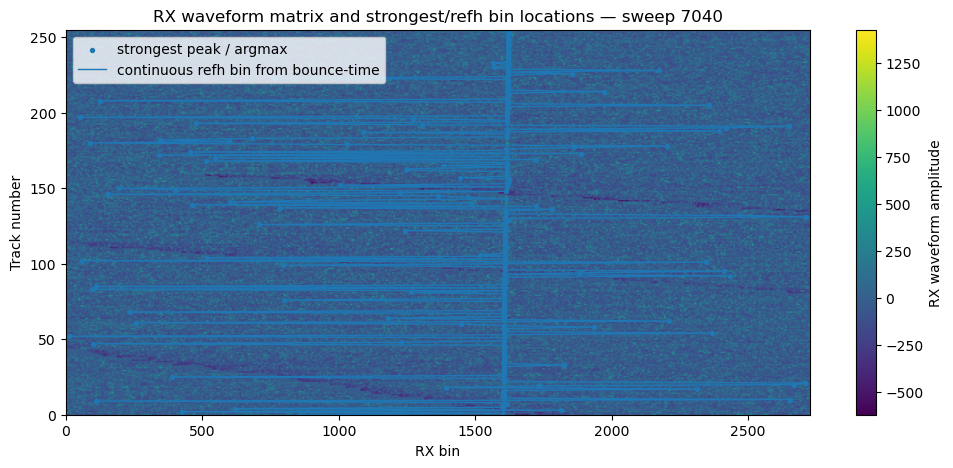

Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\ecef_interpolation_closure_to_refh.png


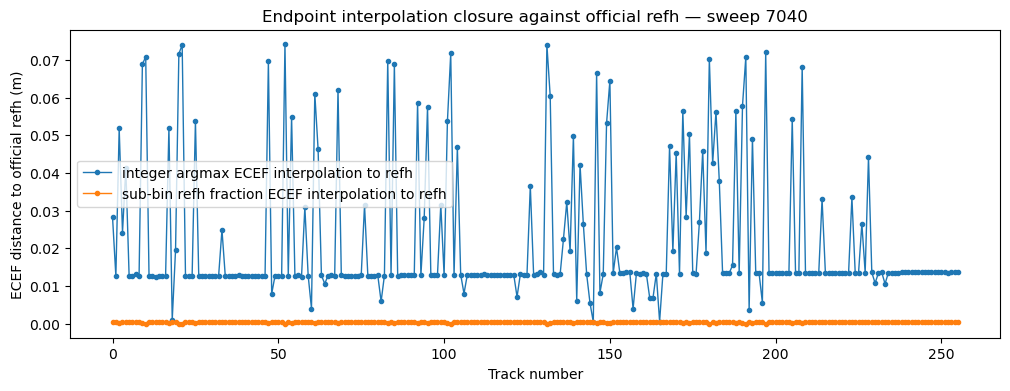

Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\interpolation_method_differences.png


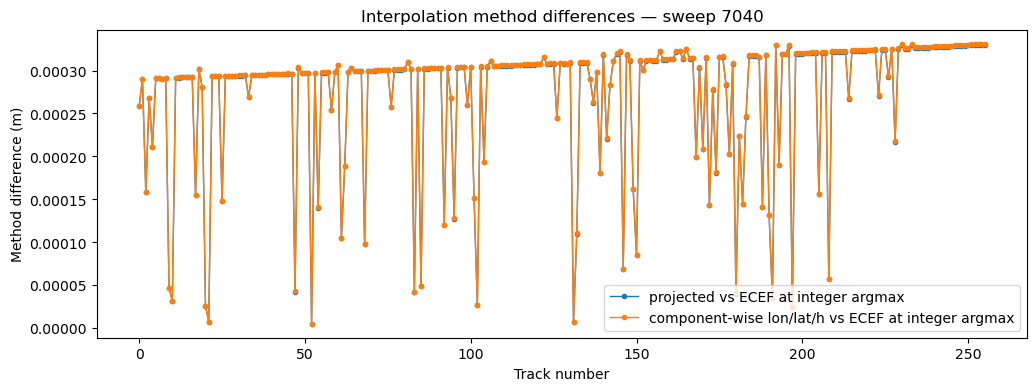

Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\endpoint_refh_ecef_interpolated_map.png


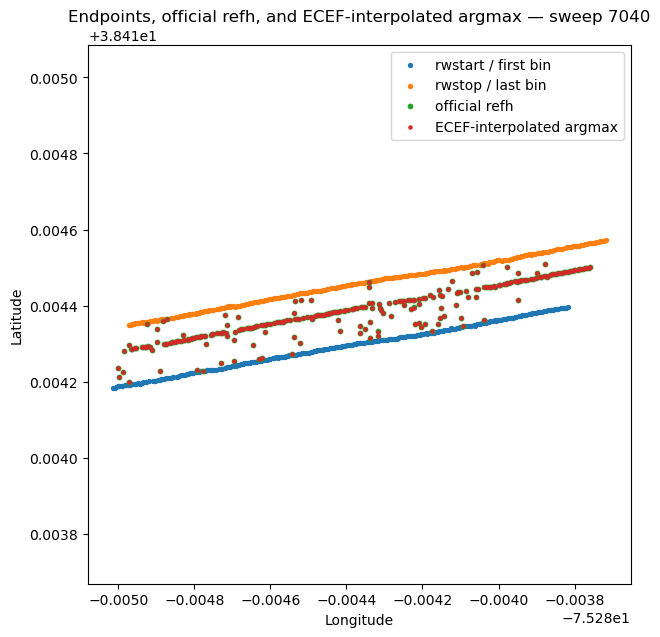

In [10]:
def savefig(out_dir: Path, name: str) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / name
    plt.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    print("Wrote:", path)


out_dir = OUT_ROOT / H5_PATH.stem / f"sweep_{sweep_data.sweep_num:05d}"
out_dir.mkdir(parents=True, exist_ok=True)

rx_display = sweep_data.rx if MAX_WAVEFORM_DISPLAY_BINS is None else sweep_data.rx[:, :MAX_WAVEFORM_DISPLAY_BINS]

plt.figure(figsize=(12, 5))
plt.imshow(
    rx_display,
    aspect="auto",
    origin="lower",
    extent=[0, rx_display.shape[1] - 1, np.min(sweep_data.track_num), np.max(sweep_data.track_num)],
)
plt.colorbar(label="RX waveform amplitude")
plt.scatter(
    strongest_geo_df["strongest_peak_bin"],
    strongest_geo_df["track_num"],
    s=8,
    label="strongest peak / argmax",
)
if has_time_offsets:
    plt.plot(
        strongest_geo_df["predicted_refh_bin_float"],
        strongest_geo_df["track_num"],
        linewidth=1,
        label="continuous refh bin from bounce-time",
    )
plt.xlabel("RX bin")
plt.ylabel("Track number")
plt.title(f"RX waveform matrix and strongest/refh bin locations — sweep {sweep_data.sweep_num}")
plt.legend(loc="best")
savefig(out_dir, "waveform_matrix_argmax_and_refh_bins.png")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(
    strongest_geo_df["track_num"],
    strongest_geo_df["argmax_bin_ecef_ecef_distance_to_refh_m"],
    marker=".",
    linewidth=1,
    label="integer argmax ECEF interpolation to refh",
)
if len(refh_fraction_geo_df):
    plt.plot(
        refh_fraction_geo_df["track_num"],
        refh_fraction_geo_df["refh_subbin_ecef_ecef_distance_to_refh_m"],
        marker=".",
        linewidth=1,
        label="sub-bin refh fraction ECEF interpolation to refh",
    )
plt.xlabel("Track number")
plt.ylabel("ECEF distance to official refh (m)")
plt.title(f"Endpoint interpolation closure against official refh — sweep {sweep_data.sweep_num}")
plt.legend()
savefig(out_dir, "ecef_interpolation_closure_to_refh.png")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(
    strongest_geo_df["track_num"],
    strongest_geo_df["argmax_bin_projected_vs_ecef_ecef_diff_m"],
    marker=".",
    linewidth=1,
    label="projected vs ECEF at integer argmax",
)
plt.plot(
    strongest_geo_df["track_num"],
    strongest_geo_df["argmax_bin_component_vs_ecef_ecef_diff_m"],
    marker=".",
    linewidth=1,
    label="component-wise lon/lat/h vs ECEF at integer argmax",
)
plt.xlabel("Track number")
plt.ylabel("Method difference (m)")
plt.title(f"Interpolation method differences — sweep {sweep_data.sweep_num}")
plt.legend()
savefig(out_dir, "interpolation_method_differences.png")
plt.show()

plt.figure(figsize=(7, 7))
plt.scatter(strongest_geo_df["rwstart_lon"], strongest_geo_df["rwstart_lat"], s=8, label="rwstart / first bin")
plt.scatter(strongest_geo_df["rwstop_lon"], strongest_geo_df["rwstop_lat"], s=8, label="rwstop / last bin")
plt.scatter(strongest_geo_df["refh_lon"], strongest_geo_df["refh_lat"], s=10, label="official refh")
plt.scatter(strongest_geo_df["argmax_bin_ecef_lon"], strongest_geo_df["argmax_bin_ecef_lat"], s=5, label="ECEF-interpolated argmax")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Endpoints, official refh, and ECEF-interpolated argmax — sweep {sweep_data.sweep_num}")
plt.legend()
plt.axis("equal")
savefig(out_dir, "endpoint_refh_ecef_interpolated_map.png")
plt.show()


## 9. Export CSV and JSON outputs


In [11]:
def json_safe_value(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v) if np.isfinite(v) else None
    if isinstance(v, np.ndarray):
        return [json_safe_value(x) for x in v.tolist()]
    if isinstance(v, (bytes, bytearray)):
        return v.decode("utf-8", errors="replace")
    if isinstance(v, Path):
        return str(v)
    return v


strongest_csv = out_dir / "strongest_peak_georef_validation.csv"
refh_subbin_csv = out_dir / "refh_subbin_georef_validation.csv"
local_peaks_csv = out_dir / "local_peak_derived_georef.csv"
summary_csv = out_dir / "sweep_georef_validation_summary.csv"
summary_json = out_dir / "sweep_georef_validation_summary.json"

strongest_geo_df.to_csv(strongest_csv, index=False)
local_peak_geo_df.to_csv(local_peaks_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

if len(refh_fraction_geo_df):
    refh_fraction_geo_df.to_csv(refh_subbin_csv, index=False)

summary_payload = {
    "h5_path": str(H5_PATH),
    "h5_file": H5_PATH.name,
    "sweep_num": int(sweep_data.sweep_num),
    "n_tracks": int(len(sweep_data.track_num)),
    "n_rx_bins": int(sweep_data.n_bins),
    "record_index_min": int(np.min(sweep_data.record_indices)),
    "record_index_max": int(np.max(sweep_data.record_indices)),
    "selected_sweep_num_config": SELECTED_SWEEP_NUM,
    "projected_epsg": int(PROJECTED_EPSG),
    "projected_crs": PROJECTED_CRS.to_string(),
    "primary_interpolation_rule": "ECEF Cartesian interpolation between rwstart and rwstop",
    "secondary_interpolation_rule": "Local projected-coordinate interpolation between rwstart and rwstop",
    "provider_literal_check": "Component-wise interpolation of longitude, latitude, and height",
    "top_local_peaks_per_track": int(TOP_LOCAL_PEAKS_PER_TRACK),
    "local_peak_min_distance_bins": int(LOCAL_PEAK_MIN_DISTANCE_BINS),
    "local_peak_min_prominence_sigma": float(LOCAL_PEAK_MIN_PROMINENCE_SIGMA),
    "has_time_offsets": bool(has_time_offsets),
    "dataset_paths": paths,
    "summary_table": [{k: json_safe_value(v) for k, v in row.items()} for row in summary_df.to_dict(orient="records")],
}

summary_json.write_text(json.dumps(summary_payload, indent=2), encoding="utf-8")

print("Wrote:", strongest_csv)
if len(refh_fraction_geo_df):
    print("Wrote:", refh_subbin_csv)
print("Wrote:", local_peaks_csv)
print("Wrote:", summary_csv)
print("Wrote:", summary_json)


Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\strongest_peak_georef_validation.csv
Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\refh_subbin_georef_validation.csv
Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\local_peak_derived_georef.csv
Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\sweep_georef_validation_summary.csv
Wrote: c:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\sweep_peak_georef_rigorous_validation\casals_l1b_20241112T165718_001_02\sweep_07040\sweep_georef_validation_summary.j

## 10. Interpretation guide

Use the following hierarchy when interpreting the output.

### Strongest evidence

If `refh_subbin_ecef_to_refh` has near-zero residuals, the endpoint georeferencing rule is strongly supported. This is the strictest internal test because it uses the official continuous `refh` time fraction and interpolates in a 3D Cartesian coordinate system.

### Integer argmax evidence

If `argmax_integer_ecef_to_refh` has centimeter-level residuals, compare it with the expected half-bin spacing. A nonzero residual is normal because the RX argmax bin is an integer index while the official `refh` can have a continuous sub-bin time position.

### Projected-coordinate implementation

If `argmax_integer_projected_to_refh` and `refh_subbin_projected_to_refh` are close to the ECEF results, a local projected-coordinate implementation is also acceptable for this small spatial extent.

### Component-wise lon/lat/h check

If `component_vs_ecef` is very small, then the provider-literal longitude/latitude/elevation interpolation is numerically valid for this dataset scale. However, ECEF or projected-coordinate interpolation should remain the primary implementation.

### Local peaks

Additional local peaks can be assigned derived coordinates, but they should be described as derived waveform peaks rather than official CASALS discrete returns.
